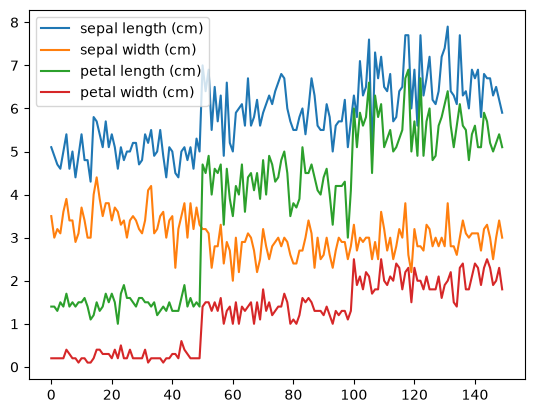

In [7]:
###########################################################
# Feature selection Modèle de sélection de caractéristiques
###########################################################

# variance threshold : élimine les caractéristiques dont la variance est inférieure à un seuil donné. Cela peut être utile pour supprimer les caractéristiques qui ne varient pas beaucoup et qui sont donc peu informatives.

# Importer VarianceThreshold pour sélectionner les variables
# qui ont une variance suffisante
from sklearn.feature_selection import VarianceThreshold

# Importer le jeu de données Iris
from sklearn.datasets import load_iris

import matplotlib.pyplot as plt

import numpy as np


# Charger le dataset Iris
iris = load_iris()

# Récupérer les variables explicatives
X = iris.data

# Récupérer la variable cible
y = iris.target


# Tracer les différentes variables
plt.plot(X)

# Ajouter les noms des variables dans la légende
plt.legend(iris.feature_names)




In [9]:
X.var(axis=0)  # Calculer la variance de chaque variable


array([0.68112222, 0.18871289, 3.09550267, 0.57713289])

In [10]:
Selector = VarianceThreshold(threshold=0.2)  # Créer un objet VarianceThreshold avec un seuil de 0.2
Selector.fit(X)  # Ajuster le sélecteur aux données

VarianceThreshold(threshold=0.2)

In [12]:
Selector.get_support()  # Obtenir un masque booléen indiquant quelles caractéristiques ont été sélectionnées

array([ True, False,  True,  True])

In [13]:
iris.feature_names  # Obtenir les noms des caractéristiques du jeu de données Iris

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [15]:
np.array(iris.feature_names)[Selector.get_support()]  # Obtenir les noms des caractéristiques sélectionnées

array(['sepal length (cm)', 'petal length (cm)', 'petal width (cm)'],
      dtype='<U17')

In [21]:
########################################################################################
# select test kbest : sélectionne les caractéristiques les plus pertinentes en fonction
#  de leur relation avec la variable cible. Cela peut être utile pour identifier les 
# caractéristiques qui ont le plus d'impact sur la variable cible.
########################################################################################

from sklearn.feature_selection import SelectKBest, chi2

chi2(X, y)  # Calculer le test du chi2 pour chaque caractéristique par rapport à la variable cible

(array([ 10.81782088,   3.7107283 , 116.31261309,  67.0483602 ]),
 array([4.47651499e-03, 1.56395980e-01, 5.53397228e-26, 2.75824965e-15]))

In [22]:
selector  = SelectKBest(score_func=chi2, k=2)  # Créer un objet SelectKBest pour sélectionner les 2 meilleures caractéristiques
selector.fit(X, y)  # Ajuster le sélecteur aux données et à la variable cible
selector.get_support()  # Obtenir un masque booléen indiquant quelles caractéristiques ont été sélectionnées


array([False, False,  True,  True])

In [26]:
#SelectFromModel : 
# sélectionne les caractéristiques en fonction de l'importance des caractéristiques 
# d'un modèle d'apprentissage automatique. Cela peut être utile pour identifier les
#  caractéristiques qui ont le plus d'impact sur la performance du modèle.


from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import SGDClassifier

selector = SelectFromModel(SGDClassifier(random_state=0), threshold='mean')  
# Créer un objet SelectFromModel avec un modèle SGDClassifier et un seuil basé sur la moyenne
#  de l'importance des caractéristiques
selector.fit_transform(X, y)  
# Ajuster le sélecteur aux données et à la variable cible, puis transformer les données
selector.get_support()  
# Obtenir un masque booléen indiquant quelles caractéristiques ont été sélectionnées
selector.estimator_.coef_  
# Obtenir les coefficients du modèle utilisé pour la sélection des caractéristiques


array([[  3.52056329,  11.04176668, -16.48263722,  -7.36117779],
       [ -5.48888269, -58.79616709,  22.88584985, -54.14457159],
       [-81.28026953, -75.17372078, 130.76437145, 131.39608339]])

In [29]:
y.shape
selector.get_support() 
# Obtenir un masque booléen indiquant quelles caractéristiques ont été sélectionnées

array([False, False,  True,  True])

In [33]:
#RFE (Recursive Feature Elimination) : 
# sélectionne les caractéristiques en éliminant de manière récursive les moins importantes. 
# Cela peut être utile pour identifier les caractéristiques qui ont le plus d'impact sur 
# la performance du modèle.
#RFECV (Recursive Feature Elimination with Cross-Validation) selectionne les caractéristiques
#  en éliminant de manière récursive les moins importantes, accompagné d'une validation croisée 
# pour déterminer le nombre optimal de caractéristiques à sélectionner. Cela peut être utile pour 
# identifier les caractéristiques qui ont le plus d'impact sur la performance du modèle tout en 
# évitant le surapprentissage.

from sklearn.feature_selection import RFE, RFECV

selector = RFECV(SGDClassifier(random_state=0),step=1, cv=5,min_features_to_select=2) 
# modèle de sélection de caractéristiques avec validation croisée qui élimine de manière 
# récursive les moins importantes
selector.fit(X, y)
selector.get_support()  # Obtenir un masque booléen indiquant quelles caractéristiques ont été sélectionnées



array([False,  True,  True,  True])

In [37]:
selector.ranking_

array([2, 1, 1, 1])

In [39]:
selector.grid_scores_  # Obtenir les scores de validation croisée pour chaque nombre de caractéristiques sélectionnées

AttributeError: 'RFECV' object has no attribute 'grid_scores_'